In [5]:
import r2l
import random
import numpy as np
import torch
import rl_utils
from tqdm import tqdm
import gymnasium as gym
import matplotlib.pyplot as plt

In [2]:
learning_rate = 1e-3
num_episodes = 1000
hidden_dim = 128
gamma = 0.98
device = r2l.get_gpu()

env_name = 'CartPole-v0'
env = gym.make(env_name)
env.reset(seed=0)
torch.manual_seed(0)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
agent  = r2l.REINFORCE(state_dim, hidden_dim, action_dim, learning_rate, gamma, device)


/home/austin/.conda/envs/r2l/lib/python3.12/site-packages/gymnasium/envs/registration.py:519: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


In [3]:
return_list = []
for i in range(10):
    with tqdm(total=int(num_episodes/10), desc='Iteration %d' % i) as pbar:
        for i_episode in range(int(num_episodes/10)):
            episode_return = 0
            transition_dict = {'states': [], 'actions': [], 'next_states': [], 'rewards': [], 'dones': []}
            state, _ = env.reset()
            done = False
            while not done:
                action = agent.take_action(state)
                next_state, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                transition_dict['states'].append(state)
                transition_dict['actions'].append(action)
                transition_dict['rewards'].append(reward)
                transition_dict['next_states'].append(next_state)
                transition_dict['dones'].append(done)
                state = next_state
                episode_return += reward
            return_list.append(episode_return)
            agent.update(transition_dict)
            if (i_episode + 1) % 10 == 0:
                pbar.set_postfix({'episode': '%d' %(num_episodes/10 * i + i_episode + 1),
                                  'return': '%.3f' % np.mean(return_list[-10:])})
            pbar.update(1)
                

Iteration 0:   0%|          | 0/100 [00:00<?, ?it/s]/home/austin/workspace/d2l/src/r2l.py:877: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.softmax(self.fc2(x))
Iteration 9: 100%|██████████| 100/100 [00:04<00:00, 21.79it/s, episode=1000, return=200.000]


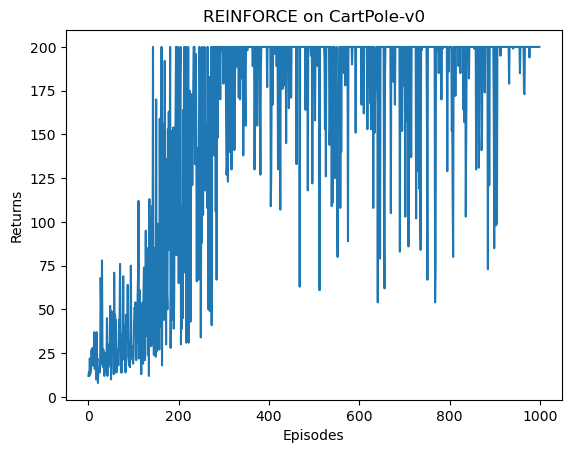

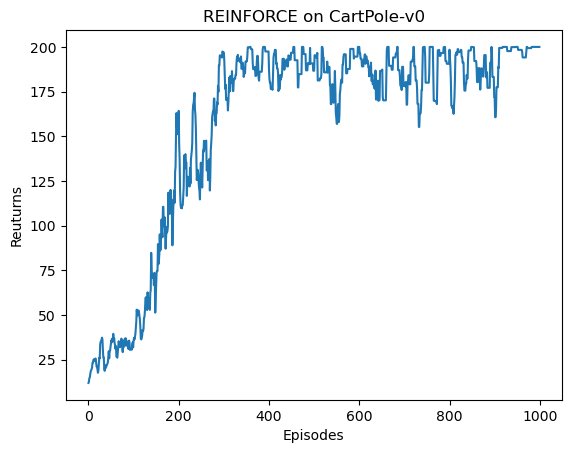

In [6]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('REINFORCE on {}'.format(env_name))
plt.show()

mv_return = rl_utils.moving_average(return_list, 9)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Reuturns')
plt.title('REINFORCE on {}'.format(env_name))
plt.show()

随着轨迹越来越多，REINFORCE算法有效的学习到了最有策略。不过相比前面的算法，他使用了更多的序列，这是因为他是在线策略算法，之前收集的数据会被废弃。此外算法的性能有一定程度的波动，这是因为每一条采样的轨迹的回报值波动比较大，这是他的不足之处